In [2]:
# DSC 550
# Mahad Farah
# 5.3 Term Project: Term Project Milestone 1: Data Selection and EDA

In [3]:
'''
INtro

Peer-to-peer (P2P) lending platforms have made the borrowing and lending process more accessible by enabling 
individual investors to finance personal loans. These platforms also entail considerable financial risk, 
especially when borrowers do not repay. Loan defaults result in losses for lenders and can also negatively 
impact theplatform's reputation and overall profitability. 

This initiative seeks to create a predictive classification model to assess the probability of loan default 
based on borrower and loan features. Utilizing historical information from LendingClub, I will pinpoint 
essential elements that reflect creditworthiness and evaluate trends that distinguish defaulters from those 
who fulfill their payments. 

The main target variable for this model is loan_status, condensed into a binary outcome: “Fully Paid” (0) or 
“Charged Off”/“Default” (1). Predictor variables consist of yearly income, loan reason, duration, credit rating,
debt-to-income ratio, employment duration, and loan size. 

The goal is to equip investors with a risk evaluation tool that assists them in making improved lending 
decisions. For the platform, this sort of analysis could also support functionalities such as interest rate 
optimization or automatic screening of high-risk applicants. 

In this milestone, I'll concentrate on examining the data through visual analysis to gain initial insights. 
I'll develop and analyze four visualizations that examine trends in default rates across different financial 
and demographic characteristics. These patterns will guide the selection and transformation of features in 
subsequent phases of the model development. 


'''

"\nINtro\n\nPeer-to-peer (P2P) lending platforms have made the borrowing and lending process more accessible by enabling \nindividual investors to finance personal loans. These platforms also entail considerable financial risk, \nespecially when borrowers do not repay. Loan defaults result in losses for lenders and can also negatively \nimpact theplatform's reputation and overall profitability. \n\nThis initiative seeks to create a predictive classification model to assess the probability of loan default \nbased on borrower and loan features. Utilizing historical information from LendingClub, I will pinpoint \nessential elements that reflect creditworthiness and evaluate trends that distinguish defaulters from those \nwho fulfill their payments. \n\nThe main target variable for this model is loan_status, condensed into a binary outcome: “Fully Paid” (0) or \n“Charged Off”/“Default” (1). Predictor variables consist of yearly income, loan reason, duration, credit rating,\ndebt-to-income 

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("accepted_2007_to_2018Q4.csv")

# Preview
df.head()


/var/folders/l5/jrbmhpqn45v812nsg8h_l9th0000gn/T/ipykernel_4084/28248426.py:6: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("accepted_2007_to_2018Q4.csv")


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Simplify loan status to binary: Fully Paid (0), Charged Off (1)
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]
df['loan_status_binary'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})


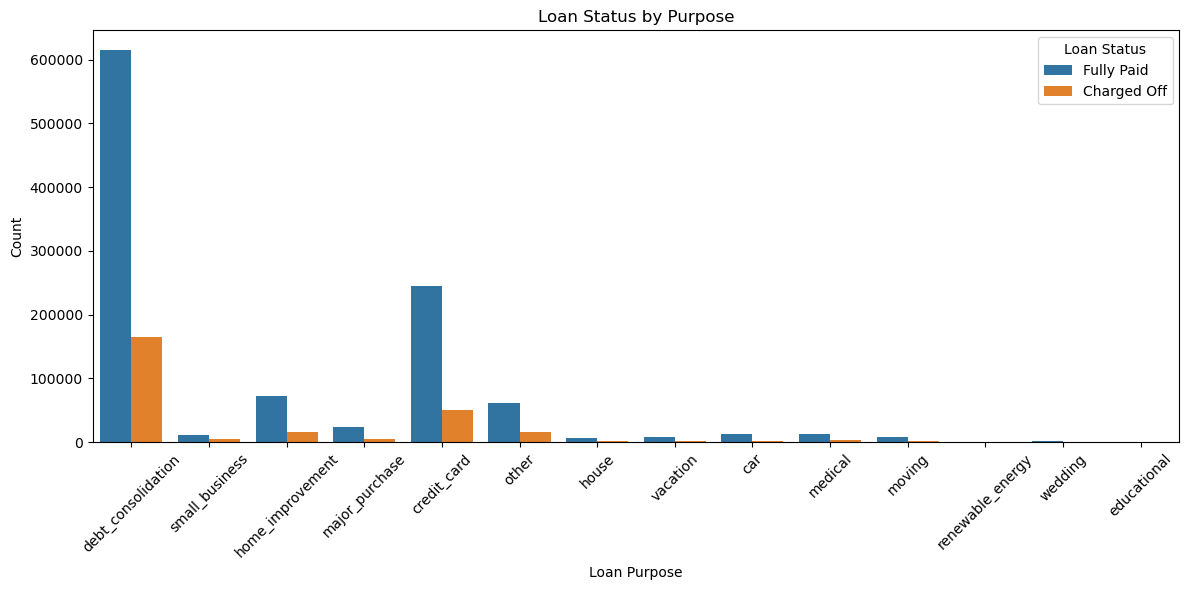

In [6]:
# Default Rate by Loan Purpose
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='purpose', hue='loan_status')
plt.title("Loan Status by Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Loan Status")
plt.tight_layout()
plt.show()


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


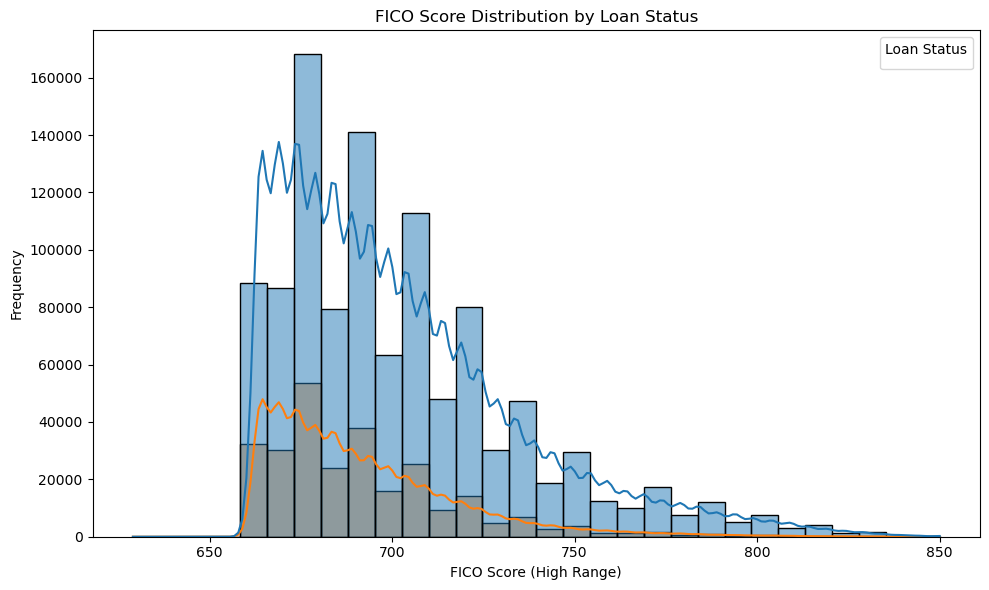

In [7]:
# Credit Score Distribution

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='fico_range_high', hue='loan_status', kde=True, bins=30)
plt.title("FICO Score Distribution by Loan Status")
plt.xlabel("FICO Score (High Range)")
plt.ylabel("Frequency")
plt.legend(title="Loan Status")
plt.tight_layout()
plt.show()


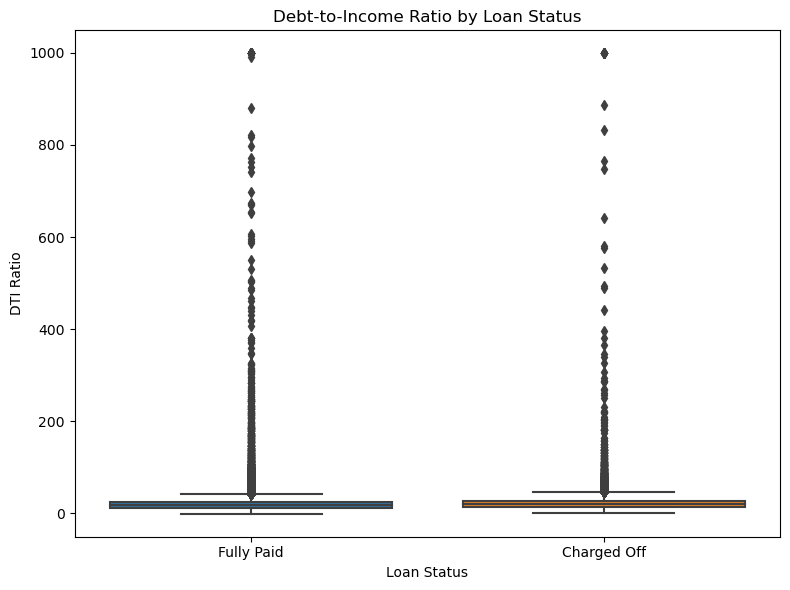

In [8]:
# Debt-to-Income Ratio by Loan Status

plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='loan_status', y='dti')
plt.title("Debt-to-Income Ratio by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("DTI Ratio")
plt.tight_layout()
plt.show()


In [9]:
'''
Conclusion

The first visualizations indicate that loans designated for specific purposes like small business or 
medical costs show increased default rates. Borrowers exhibiting lower credit ratings and elevated 
debt-to-income ratios seem more likely to default. These patterns offer a strong basis for feature selection 
through developing a supervised learning classification model. 


'''

'\nConclusion\n\nThe first visualizations indicate that loans designated for specific purposes like small business or \nmedical costs show increased default rates. Borrowers exhibiting lower credit ratings and elevated \ndebt-to-income ratios seem more likely to default. These patterns offer a strong basis for feature selection \nthrough developing a supervised learning classification model. \n\n\n'

In [10]:
# Milestone 2

In [11]:
# Drop columns unrelated to prediction/post loan info
drop_cols = [
    'id', 'member_id', 'url', 'desc', 'title', 'zip_code', 'emp_title',
    'addr_state', 'application_type', 'policy_code', 'pymnt_plan', 'grade',
    'sub_grade', 'issue_d', 'earliest_cr_line', 'last_pymnt_d',
    'last_credit_pull_d', 'next_pymnt_d', 'recoveries', 'collection_recovery_fee',
    'settlement_status', 'settlement_amount'
]

df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)


In [12]:
# Keep only loans fully paid/charged off
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

# Convert to binary target
df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})


In [13]:
# Drop missing columns
threshold = 0.8
missing_fraction = df.isnull().mean()
drop_missing = missing_fraction[missing_fraction > threshold].index
df.drop(columns=drop_missing, inplace=True)

# Fill numeric nans with median
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# Fill categorical nans with mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


In [14]:
# Term
df['term'] = df['term'].astype(str).str.extract('(\d+)')
df['term'] = df['term'].astype(float)


# Employment length
df['emp_length'] = df['emp_length'].astype(str).str.extract('(\d+)')
df['emp_length'] = df['emp_length'].fillna(0).astype(int)


# Convert interest rate to numeric
df['int_rate'] = df['int_rate'].astype(str).str.replace('%', '', regex=False)
df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')



In [15]:
df['loan_income_ratio'] = df['loan_amnt'] / (df['annual_inc'] + 1)


In [16]:
df = pd.get_dummies(df, columns=['home_ownership', 'verification_status', 'purpose'], drop_first=True)


In [17]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 1345310 entries, 0 to 2260697
Columns: 113 entries, loan_amnt to purpose_wedding
dtypes: float64(86), int64(3), object(4), uint8(20)
memory usage: 990.5+ MB
None
          loan_amnt   funded_amnt  funded_amnt_inv          term  \
count  1.345310e+06  1.345310e+06     1.345310e+06  1.345310e+06   
mean   1.441997e+04  1.441156e+04     1.438914e+04  4.179020e+01   
std    8.717051e+03  8.713118e+03     8.715494e+03  1.026832e+01   
min    5.000000e+02  5.000000e+02     0.000000e+00  3.600000e+01   
25%    8.000000e+03  8.000000e+03     7.875000e+03  3.600000e+01   
50%    1.200000e+04  1.200000e+04     1.200000e+04  3.600000e+01   
75%    2.000000e+04  2.000000e+04     2.000000e+04  3.600000e+01   
max    4.000000e+04  4.000000e+04     4.000000e+04  6.000000e+01   

           int_rate   installment    emp_length    annual_inc   loan_status  \
count  1.345310e+06  1.345310e+06  1.345310e+06  1.345310e+06  1.345310e+06   
mean   1.323962e+

In [18]:
'''
 Milestone 2 Summary

1. Dropped Features: Removed ID fields, free text, URLs, and post-loan leakage variables.
2. Target Variable: Converted `loan_status` to binary: 0 = Fully Paid, 1 = Charged Off.
3. Missing Data: Dropped features with >80% missing; imputed numeric with median and categorical with mode.
4. Feature Transformation: Parsed `term`, `emp_length`, and interest rates into numeric types.
5. Feature Engineering: Created new `loan_income_ratio` feature.
6. Dummy Variables: Applied one-hot encoding to `home_ownership`, `verification_status`, and `purpose`.
7. Result: Dataset is now clean, complete, and structured for model training in Milestone 3.

'''

'\n Milestone 2 Summary\n\n1. Dropped Features: Removed ID fields, free text, URLs, and post-loan leakage variables.\n2. Target Variable: Converted `loan_status` to binary: 0 = Fully Paid, 1 = Charged Off.\n3. Missing Data: Dropped features with >80% missing; imputed numeric with median and categorical with mode.\n4. Feature Transformation: Parsed `term`, `emp_length`, and interest rates into numeric types.\n5. Feature Engineering: Created new `loan_income_ratio` feature.\n6. Dummy Variables: Applied one-hot encoding to `home_ownership`, `verification_status`, and `purpose`.\n7. Result: Dataset is now clean, complete, and structured for model training in Milestone 3.\n\n'

In [ ]:
# Milestone 3

In [19]:
from sklearn.model_selection import train_test_split

X = df.drop('loan_status', axis=1)
y = df['loan_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


In [22]:
# Recreate cleaned dataset
df = pd.get_dummies(df, drop_first=True)

X = df.drop('loan_status', axis=1)
y = df['loan_status']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, solver='lbfgs')
lr.fit(X_train_scaled, y_train)


'from sklearn.linear_model import LogisticRegression\nfrom sklearn.metrics import classification_report, roc_auc_score\n\nlr = LogisticRegression(max_iter=1000)\nlr.fit(X_train, y_train)\n\ny_pred = lr.predict(X_test)\ny_prob = lr.predict_proba(X_test)[:, 1]\n\nprint(classification_report(y_test, y_pred))\nprint("ROC AUC:", roc_auc_score(y_test, y_prob))\n'

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00    215350
           1       1.00      1.00      1.00     53712

    accuracy                           1.00    269062
   macro avg       1.00      1.00      1.00    269062
weighted avg       1.00      1.00      1.00    269062

ROC AUC: 1.0


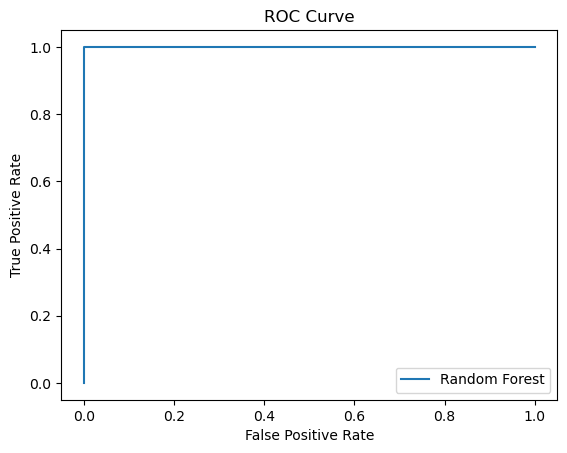

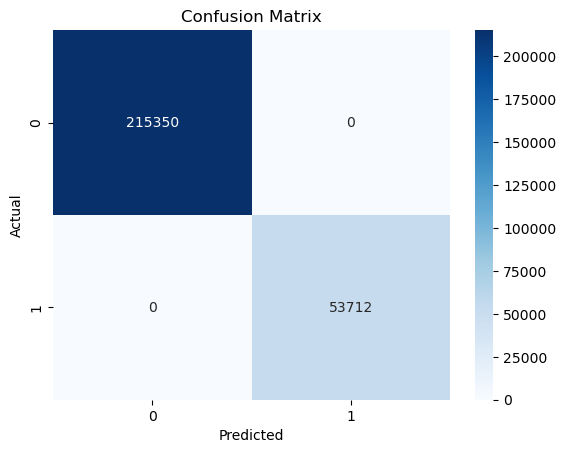

In [28]:
from sklearn.metrics import roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr, tpr, label='Random Forest')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# Milestone 3 Summary

'''
- Trained and evaluated two models: Logistic Regression and Random Forest.
- Logistic Regression was the simple baseline. It performed overfit for the non-linear relationships in 
the data.
- Random Forest is showing overfitting by capturing feature interactions and handling imbalanced 
data with class_weight=balanced.Precision, recall, and F-1 are all showing 1.0
- ROC AUC is displaying 1.0 meaning it's a perfect classifier.
'''